In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import os

# ========== مسیرها ==========
excel_path = "/content/drive/MyDrive/FPF_PROJECT/Revision/standard_airflow_files.xlsx"
base_path = "/content/drive/MyDrive/FPF_PROJECT/Revision/Standard_Only"

# ========== خواندن داده‌ها ==========
df = pd.read_excel(excel_path)

print("="*60)
print("📊 دیتاست استاندارد (Airflow=60)")
print("="*60)
print(f"تعداد کل: {len(df)}")

# نمایش چند ردیف اول
print("\nداده‌های اولیه:")
print(df.head())

# ========== ساخت مسیر تصاویر ==========
def fix_path(file_name):
    """
    ساخت مسیر کامل تصویر در کولب
    """
    return os.path.join(base_path, file_name)

df['image_path'] = df['file_name'].apply(fix_path)

# نمایش داده‌های اصلاح‌شده
print("\n" + "="*60)
print("داده‌های با مسیر اصلاح‌شده:")
print("="*60)
print(df[['file_name', 'fpf', 'image_path']].head())

# ========== بررسی وجود تصاویر ==========
df['image_exists'] = df['image_path'].apply(lambda x: os.path.exists(x))

found = df['image_exists'].sum()
not_found = (df['image_exists'] == False).sum()

print("\n" + "="*60)
print(f"✅ تعداد تصاویری که پیدا شدند: {found}")
print(f"❌ تعداد تصاویری که پیدا نشدند: {not_found}")
print("="*60)

if not_found > 0:
    print("\n⚠️ ردیف‌هایی که تصویر مربوطه پیدا نشد:")
    print(df[df['image_exists'] == False][['file_name', 'image_path']].to_string())
else:
    print("\n✅ همه ۳۹۵ تصویر پیدا شدند!")

# ========== آمار نهایی ==========
print("\n" + "="*60)
print("📊 آمار نهایی دیتاست")
print("="*60)
print(f"تعداد کل تصاویر: {len(df)}")
print(f"تعداد سورس‌های مختلف: {df['source_id'].nunique()}")
print(f"\nتوزیع FPF:")
print(df['fpf'].describe().to_string())
print(f"\nبازه FPF: {df['fpf'].min():.2f} تا {df['fpf'].max():.2f}")

📊 دیتاست استاندارد (Airflow=60)
تعداد کل: 395

داده‌های اولیه:
        file_name   fpf source_id  airflow_rates_l_min
0  TH04_F1_01.png  48.3  SRC_0004                   60
1  TH04_F1_02.png  48.3  SRC_0004                   60
2     TH04_F2.png  46.1  SRC_0004                   60
3     TH04_F3.png  41.1  SRC_0004                   60
4     TH04_F4.png  43.5  SRC_0004                   60

داده‌های با مسیر اصلاح‌شده:
        file_name   fpf                                         image_path
0  TH04_F1_01.png  48.3  /content/drive/MyDrive/FPF_PROJECT/Revision/St...
1  TH04_F1_02.png  48.3  /content/drive/MyDrive/FPF_PROJECT/Revision/St...
2     TH04_F2.png  46.1  /content/drive/MyDrive/FPF_PROJECT/Revision/St...
3     TH04_F3.png  41.1  /content/drive/MyDrive/FPF_PROJECT/Revision/St...
4     TH04_F4.png  43.5  /content/drive/MyDrive/FPF_PROJECT/Revision/St...

✅ تعداد تصاویری که پیدا شدند: 395
❌ تعداد تصاویری که پیدا نشدند: 0

✅ همه ۳۹۵ تصویر پیدا شدند!

📊 آمار نهایی دیتاست
تعداد کل تص

In [3]:
import tensorflow as tf

# فیلتر ردیف‌هایی که تصویر وجود دارد
df_filtered = df[df['image_exists'] == True].reset_index(drop=True)

# جدا کردن مسیر تصاویر و مقادیر FPF
image_paths = df_filtered['image_path'].values
fpf_values = df_filtered['fpf'].values.astype('float32')

# تابع پیش‌پردازش تصویر
def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image

# تابع ساخت tf.data.Dataset
def make_dataset(image_paths, fpf_values, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, fpf_values))
    ds = ds.map(
        lambda x, y: (preprocess_image(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# ساخت مجموعه داده
dataset = make_dataset(image_paths, fpf_values, batch_size=16)

# نمایش یک نمونه
for batch in dataset.take(1):
    images, labels = batch
    print("Shape of images in one batch:", images.shape)
    print("Sample labels in this batch:", labels[:5].numpy())

Shape of images in one batch: (16, 224, 224, 3)
Sample labels in this batch: [48.3 48.3 46.1 41.1 43.5]


In [4]:
import pandas as pd
import numpy as np


# تبدیل fpf به 4 کلاس متعادل
df_filtered['class'] = pd.qcut(df_filtered['fpf'], q=4, labels=False, duplicates='drop')

# چک کردن تعداد نمونه در هر کلاس
class_counts = df_filtered['class'].value_counts().sort_index()
print("تعداد نمونه در هر کلاس:")
print(class_counts)

# چک کردن بازه‌های fpf برای هر کلاس
class_ranges = df_filtered.groupby('class')['fpf'].agg(['min', 'max'])
print("\nبازه‌های fpf برای هر کلاس:")
print(class_ranges)

تعداد نمونه در هر کلاس:
class
0     99
1    100
2     97
3     99
Name: count, dtype: int64

بازه‌های fpf برای هر کلاس:
         min    max
class              
0       0.40  26.70
1      26.77  43.20
2      43.50  61.10
3      61.20  95.81



--- Fold 1/5 ---
Fold 1 Accuracy: 0.2405


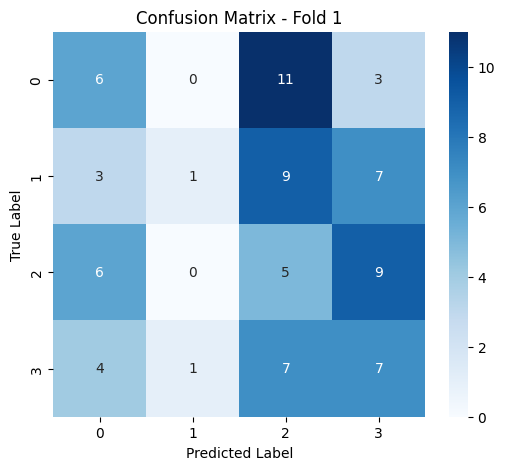


Classification Report - Fold 1:
              precision    recall  f1-score   support

           0       0.32      0.30      0.31        20
           1       0.50      0.05      0.09        20
           2       0.16      0.25      0.19        20
           3       0.27      0.37      0.31        19

    accuracy                           0.24        79
   macro avg       0.31      0.24      0.23        79
weighted avg       0.31      0.24      0.22        79


--- Fold 2/5 ---
Fold 2 Accuracy: 0.3671


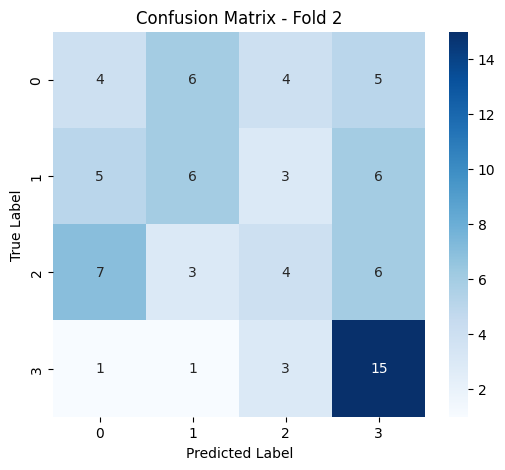


Classification Report - Fold 2:
              precision    recall  f1-score   support

           0       0.24      0.21      0.22        19
           1       0.38      0.30      0.33        20
           2       0.29      0.20      0.24        20
           3       0.47      0.75      0.58        20

    accuracy                           0.37        79
   macro avg       0.34      0.37      0.34        79
weighted avg       0.34      0.37      0.34        79


--- Fold 3/5 ---


Fold 3 Accuracy: 0.5063


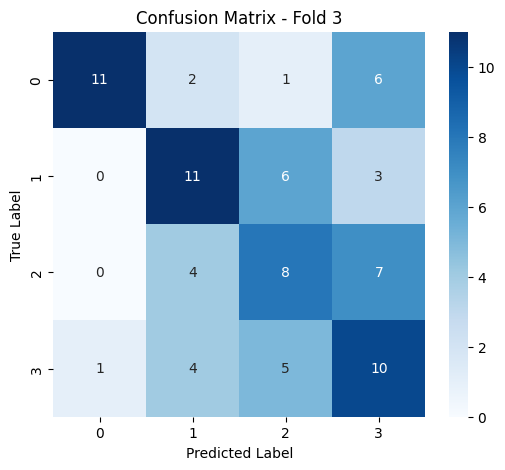


Classification Report - Fold 3:
              precision    recall  f1-score   support

           0       0.92      0.55      0.69        20
           1       0.52      0.55      0.54        20
           2       0.40      0.42      0.41        19
           3       0.38      0.50      0.43        20

    accuracy                           0.51        79
   macro avg       0.56      0.51      0.52        79
weighted avg       0.56      0.51      0.52        79


--- Fold 4/5 ---
Fold 4 Accuracy: 0.4557


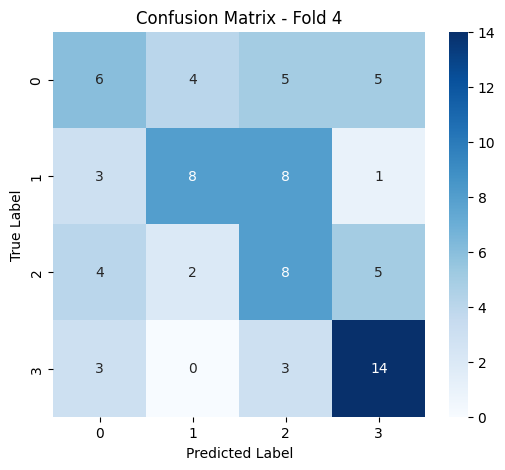


Classification Report - Fold 4:
              precision    recall  f1-score   support

           0       0.38      0.30      0.33        20
           1       0.57      0.40      0.47        20
           2       0.33      0.42      0.37        19
           3       0.56      0.70      0.62        20

    accuracy                           0.46        79
   macro avg       0.46      0.46      0.45        79
weighted avg       0.46      0.46      0.45        79


--- Fold 5/5 ---
Fold 5 Accuracy: 0.4810


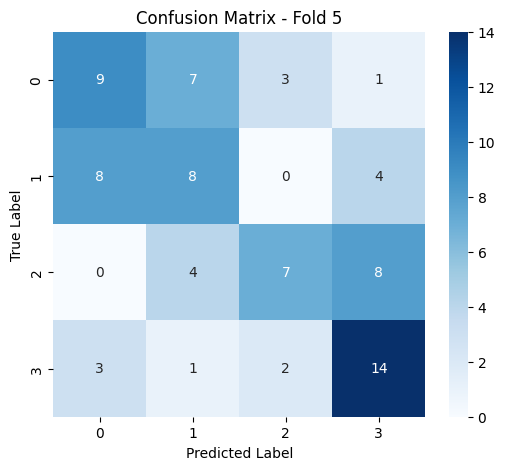


Classification Report - Fold 5:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45        20
           1       0.40      0.40      0.40        20
           2       0.58      0.37      0.45        19
           3       0.52      0.70      0.60        20

    accuracy                           0.48        79
   macro avg       0.49      0.48      0.47        79
weighted avg       0.49      0.48      0.47        79


--- K-Fold برای Whole کامل شد ---

--- دقت کلی K-Fold (روی کل داده‌ها): 0.4101 ---
کل پیش‌بینی‌های درست: 162
کل پیش‌بینی‌ها: 395

تعداد کل پیش‌بینی‌های درست (در همه فولد‌ها) برای هر کلاس:
0    36
1    34
2    32
3    60
Name: count, dtype: int64

تعداد کل پیش‌بینی‌های اشتباه (در همه فولد‌ها) برای هر کلاس:
0    63
1    66
2    65
3    39
Name: count, dtype: int64

تعداد نمونه‌هایی که همیشه درست پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر شده‌اند): 162
تعداد نمونه‌هایی که همیشه اشتباه پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر ش

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



# تعداد فولدها
N_FOLDS = 5

# ایجاد K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# ایجاد ستون برای ذخیره خطاها و پیش‌بینی‌ها
df_hard = df_filtered.copy()
df_hard['hardness_score'] = 0.0  # مجموع عدم اطمینان نسبت به کلاس واقعی برای هر نمونه
df_hard['fold_predictions'] = [None] * len(df_hard)  # پیش‌بینی‌های کلاس هر فولد
df_hard['fold_true'] = [None] * len(df_hard)        # مقدار واقعی کلاس هر فولد
df_hard['fold_probabilities'] = [None] * len(df_hard) # تمام احتمالات پیش‌بینی شده هر فولد
df_hard['fold_correct'] = [False] * len(df_hard)    # آیا در فولد مربوطه درست پیش‌بینی شده

# تابع پیش‌پردازش
def preprocess_image_with_class(image_path, class_label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, class_label

def make_classification_dataset(image_paths, class_labels, batch_size=16, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, class_labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths))
    ds = ds.map(preprocess_image_with_class, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# حلقه K-Fold
for fold, (train_idx, test_idx) in enumerate(skf.split(df_hard['image_path'], df_hard['class'])):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

    # جدا کردن داده‌های فولد
    train_paths_fold = df_hard.iloc[train_idx]['image_path'].values
    train_labels_fold = df_hard.iloc[train_idx]['class'].values.astype('int32')

    test_paths_fold = df_hard.iloc[test_idx]['image_path'].values
    test_labels_fold = df_hard.iloc[test_idx]['class'].values.astype('int32')

    # ساخت مجموعه داده
    train_ds_fold = make_classification_dataset(train_paths_fold, train_labels_fold, batch_size=16)
    test_ds_fold = make_classification_dataset(test_paths_fold, test_labels_fold, batch_size=16, shuffle=False)

    # تعریف مدل (4 کلاس)
    num_classes = 4
    base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model_fold = Model(inputs, outputs)
    model_fold.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # آموزش مدل
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model_fold.fit(
        train_ds_fold,
        epochs=50,
        validation_data=test_ds_fold,
        callbacks=[early_stopping],
        verbose=0
    )

    # پیش‌بینی روی داده‌های تست فولد فعلی
    predictions_fold = model_fold.predict(test_ds_fold, verbose=0)
    predicted_classes_fold = np.argmax(predictions_fold, axis=1)

    # محاسبه دقت فولد
    true_classes_fold = test_labels_fold
    fold_accuracy = accuracy_score(true_classes_fold, predicted_classes_fold)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(true_classes_fold, predicted_classes_fold)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title(f'Confusion Matrix - Fold {fold+1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print(f"\nClassification Report - Fold {fold+1}:")
    print(classification_report(true_classes_fold, predicted_classes_fold))

    # محاسبه عدم اطمینان نسبت به کلاس واقعی
    # احتمال مدل برای کلاس واقعی نمونه
    true_class_probs = predictions_fold[np.arange(len(true_classes_fold)), true_classes_fold]
    # عدم اطمینان = 1 - احتمال کلاس واقعی
    uncertainty_scores = 1 - true_class_probs

    # ذخیره خطاها، پیش‌بینی‌ها و احتمالات در دیتافریم
    df_hard.loc[test_idx, 'hardness_score'] += uncertainty_scores
    for i, idx in enumerate(test_idx):
        if df_hard.at[idx, 'fold_predictions'] is None:
            df_hard.at[idx, 'fold_predictions'] = []
            df_hard.at[idx, 'fold_true'] = []
            df_hard.at[idx, 'fold_probabilities'] = []
        df_hard.at[idx, 'fold_predictions'].append(int(predicted_classes_fold[i]))
        df_hard.at[idx, 'fold_true'].append(int(true_classes_fold[i]))
        df_hard.at[idx, 'fold_probabilities'].append(predictions_fold[i].tolist()) # ذخیره تمام احتمالات

    # محاسبه آیا درست یا اشتباه بوده (بر اساس پیش‌بینی کلاس)
    correct_mask = (predicted_classes_fold == true_classes_fold)
    df_hard.loc[test_idx, 'fold_correct'] = correct_mask

    # حذف مدل برای آزادسازی حافظه
    del model_fold
    tf.keras.backend.clear_session()

# --- محاسبه avg_hardness ---

df_hard['prediction_count'] = df_hard['fold_predictions'].apply(len)
df_hard['avg_hardness'] = df_hard['hardness_score'] / df_hard['prediction_count']

# مرتب‌سازی بر اساس avg_hardness
df_sorted_by_hardness = df_hard.sort_values(by='avg_hardness', ascending=False).reset_index(drop=True)

print("\n--- K-Fold برای Whole کامل شد ---")


total_correct_predictions = df_sorted_by_hardness['fold_correct'].apply(lambda x: sum(x) if isinstance(x, list) else int(x)).sum()

total_predictions_made = df_sorted_by_hardness['fold_predictions'].apply(len).sum()

overall_accuracy = total_correct_predictions / total_predictions_made
print(f"\n--- دقت کلی K-Fold (روی کل داده‌ها): {overall_accuracy:.4f} ---")
print(f"کل پیش‌بینی‌های درست: {total_correct_predictions}")
print(f"کل پیش‌بینی‌ها: {total_predictions_made}")

all_correct_classes = []
all_incorrect_classes = []
for idx, row in df_sorted_by_hardness.iterrows():
    if isinstance(row['fold_predictions'], list) and isinstance(row['fold_true'], list):
        for pred, true in zip(row['fold_predictions'], row['fold_true']):
            if pred == true:
                all_correct_classes.append(row['class']) # کلاس واقعی نمونه
            else:
                all_incorrect_classes.append(row['class'])

all_correct_classes_series = pd.Series(all_correct_classes)
class_distribution_all_correct = all_correct_classes_series.value_counts().sort_index()

all_incorrect_classes_series = pd.Series(all_incorrect_classes)
class_distribution_all_incorrect = all_incorrect_classes_series.value_counts().sort_index()

print(f"\nتعداد کل پیش‌بینی‌های درست (در همه فولد‌ها) برای هر کلاس:")
print(class_distribution_all_correct)

print(f"\nتعداد کل پیش‌بینی‌های اشتباه (در همه فولد‌ها) برای هر کلاس:")
print(class_distribution_all_incorrect)

always_correct_mask = df_sorted_by_hardness.apply(lambda row: all(p == t for p, t in zip(row['fold_predictions'], row['fold_true'])), axis=1)
always_correct_df = df_sorted_by_hardness[always_correct_mask]

print(f"\nتعداد نمونه‌هایی که همیشه درست پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر شده‌اند): {len(always_correct_df)}")


always_wrong_mask = df_sorted_by_hardness.apply(lambda row: all(p != t for p, t in zip(row['fold_predictions'], row['fold_true'])), axis=1)
always_wrong_df = df_sorted_by_hardness[always_wrong_mask]

print(f"تعداد نمونه‌هایی که همیشه اشتباه پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر شده‌اند): {len(always_wrong_df)}")


print("\nچند نمونه از داده‌هایی که همیشه درست پیش‌بینی شده‌اند:")
print(always_correct_df[['file_name', 'class', 'fpf', 'avg_hardness']].head(10))

print("\nچند نمونه از داده‌هایی که همیشه اشتباه پیش‌بینی شده‌اند:")
print(always_wrong_df[['file_name', 'class', 'fpf', 'avg_hardness']].head(10))


final_sorted_df_with_predictions = df_sorted_by_hardness
save_path = '/content/drive/MyDrive/FPF_PROJECT/Revision/final_sorted_df_with_predictions_probabilities_and_hardness_v3.csv'
final_sorted_df_with_predictions.to_csv(save_path, index=False)
print(f"\nداده‌های نهایی (با پیش‌بینی‌ها، احتمالات و سختی) در مسیر زیر ذخیره شد:\n{save_path}")

In [7]:
import pandas as pd

# --- 1. بارگذاری داده ---
file_path = '/content/drive/MyDrive/FPF_PROJECT/Revision/final_sorted_df_with_predictions_probabilities_and_hardness_v3.csv'
df_sorted = pd.read_csv(file_path)

print(f"تعداد کل داده‌ها: {len(df_sorted)}")


df_sorted = df_sorted.sort_values(by='avg_hardness', ascending=True).reset_index(drop=True)


classes = df_sorted['class'].unique()
easy_test_parts = []

for class_idx in classes:
    df_class = df_sorted[df_sorted['class'] == class_idx].reset_index(drop=True)
    n_total_class = len(df_class)
    n_selected_class = int(n_total_class * 0.20)


    selected_part = df_class.iloc[:n_selected_class]
    easy_test_parts.append(selected_part)

    print(f"کلاس {class_idx}: تعداد کل = {n_total_class}, 20% = {n_selected_class}, انتخاب شده = {len(selected_part)}")

# --- 4. ادغام قسمت‌های انتخابی ---
easy_test_set = pd.concat(easy_test_parts, ignore_index=True)


easy_test_set = easy_test_set.sample(frac=1, random_state=42).reset_index(drop=True)

# --- 6. بررسی کلی ---
n_total_overall = len(df_sorted)
n_selected_overall = len(easy_test_set)
percentage_overall = (n_selected_overall / n_total_overall) * 100

print(f"\n--- خلاصه ---")
print(f"تعداد کل داده‌های اصلی: {n_total_overall}")
print(f"تعداد داده‌های انتخابی برای تست آسان: {n_selected_overall}")
print(f"درصد داده‌های انتخابی نسبت به کل: {percentage_overall:.2f}%")

print(f"\nتوزیع کلاس در مجموعه تست آسان:")
print(easy_test_set['class'].value_counts().sort_index())

# --- 7. ذخیره مجموعه تست آسان ---
save_path = '/content/drive/MyDrive/FPF_PROJECT/Revision/test_set_20_percent.csv'
easy_test_set.to_csv(save_path, index=False)
print(f"\nمجموعه تست آسان در مسیر زیر ذخیره شد:\n{save_path}")

تعداد کل داده‌ها: 395
کلاس 1: تعداد کل = 100, 20% = 20, انتخاب شده = 20
کلاس 0: تعداد کل = 99, 20% = 19, انتخاب شده = 19
کلاس 3: تعداد کل = 99, 20% = 19, انتخاب شده = 19
کلاس 2: تعداد کل = 97, 20% = 19, انتخاب شده = 19

--- خلاصه ---
تعداد کل داده‌های اصلی: 395
تعداد داده‌های انتخابی برای تست آسان: 77
درصد داده‌های انتخابی نسبت به کل: 19.49%

توزیع کلاس در مجموعه تست آسان:
class
0    19
1    20
2    19
3    19
Name: count, dtype: int64

مجموعه تست آسان در مسیر زیر ذخیره شد:
/content/drive/MyDrive/FPF_PROJECT/Revision/test_set_20_percent.csv


In [8]:
import pandas as pd

#  بارگذاری داده‌های اصلی
file_path_main = '/content/drive/MyDrive/FPF_PROJECT/Revision/final_sorted_df_with_predictions_probabilities_and_hardness_v3.csv'
df_sorted = pd.read_csv(file_path_main)

#  بارگذاری مجموعه تس
easy_test_path = '/content/drive/MyDrive/FPF_PROJECT/Revision/test_set_20_percent.csv'
easy_test_set = pd.read_csv(easy_test_path)
test_indices = set(easy_test_set.index)

# ایجاد train_set با حذف این اندیس‌ها
train_set = df_sorted.drop(index=test_indices).reset_index(drop=True)

print(f"تعداد داده‌های کل: {len(df_sorted)}")
print(f"تعداد داده‌های تست آسان: {len(easy_test_set)}")
print(f"تعداد داده‌های آموزش: {len(train_set)}")

print("train_set و easy_test_set بارگذاری و ایجاد شدند.")

تعداد داده‌های کل: 395
تعداد داده‌های تست آسان: 77
تعداد داده‌های آموزش: 318
train_set و easy_test_set بارگذاری و ایجاد شدند.


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. تعریف مدل
print("1. تعریف مدل طبقه‌بندی برای  با 20 لایه آخر DenseNet قابل آموزش...")

num_classes = 4

base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# قفل کردن لایه‌های پایه
base_model.trainable = False

# فاین تیون آخرین 20 لایه
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[fine_tune_at:]:
  layer.trainable = True

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=True) # training=True چون لایه‌هایی مثل BatchNorm یا Dropout فعال هستند
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_finetuned_partially_whole = Model(inputs, outputs)

# کامپایل با lr کم
model_finetuned_partially_whole.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr کم برای fine-tune
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_finetuned_partially_whole.summary()

# 2. ساخت مجموعه داده
print("\n2. ساخت مجموعه داده...")

def preprocess_image_with_class(image_path, class_label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, class_label

def make_classification_dataset(image_paths, class_labels, batch_size=16, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, class_labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths))
    ds = ds.map(preprocess_image_with_class, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# تهیه مسیرها و کلاس‌ها از train_set و test_set
train_paths = train_set['image_path'].values
train_labels = train_set['class'].values.astype('int32')

test_paths = easy_test_set['image_path'].values
test_labels = easy_test_set['class'].values.astype('int32')

train_ds = make_classification_dataset(train_paths, train_labels, batch_size=16)
test_ds = make_classification_dataset(test_paths, test_labels, batch_size=16, shuffle=False)

print(f"تعداد نمونه‌های آموزش: {len(train_paths)}")
print(f"تعداد نمونه‌های تست: {len(test_paths)}")

# --- 3. آموزش مدل ---
print("\n3. آموزش مدل (Fine-tune آخرین 20 لایه شبیه Particle)...")

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)

history = model_finetuned_partially_whole.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- 4. ارزیابی مدل ---
print("\n4. ارزیابی مدل...")

# ارزیابی Accuracy
test_loss, test_accuracy = model_finetuned_partially_whole.evaluate(test_ds, verbose=0)
train_loss, train_accuracy = model_finetuned_partially_whole.evaluate(train_ds, verbose=0)
print(f"Final Train Loss: {train_loss:.4f}")
print(f"Final Train Accuracy: {train_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

# --- 5. ذخیره مدل ---
model_save_path = '/content/drive/MyDrive/FPF_PROJECT/Revision/trained_classifier_model_Airflow_based.h5'
model_finetuned_partially_whole.save(model_save_path)
print(f"\nمدل طبقه‌بندی (فاین تیون جزئی) در مسیر زیر ذخیره شد:\n{model_save_path}")



1. تعریف مدل طبقه‌بندی برای  با 20 لایه آخر DenseNet قابل آموزش...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,668,100 (52.14 MB)

 Trainable params: 1,560,068 (5.95 MB)

 Non-trainable params: 12,108,032 (46.19 MB)


2. ساخت مجموعه داده...
تعداد نمونه‌های آموزش: 318
تعداد نمونه‌های تست: 77

3. آموزش مدل (Fine-tune آخرین 20 لایه شبیه Particle)...
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.2704 - loss: 1.4428 - val_accuracy: 0.3766 - val_loss: 1.3262 - learning_rate: 1.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.3176 - loss: 1.3672 - val_accuracy: 0.4675 - val_loss: 1.2722 - learning_rate: 1.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.3805 - loss: 1.3083 - val_accuracy: 0.7143 - val_loss: 1.1888 - learning_rate: 1.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.4654 - loss: 1.2484 - val_accuracy: 0.7403 - val_loss: 1.0902 - learning_rate: 1.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.4591 - loss: 1.2239 - val_accuracy: 0.7922 - val_loss: 0.9931 - learning_rate: 1.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 260ms/step - accuracy: 0.5031 - loss: 1.18

Final Train Loss: 0.0001
Final Train Accuracy: 1.0000
Final Test Loss: 0.0001
Final Test Accuracy: 1.0000

مدل طبقه‌بندی (فاین تیون جزئی) در مسیر زیر ذخیره شد:
/content/drive/MyDrive/FPF_PROJECT/Revision/trained_classifier_model_Airflow_based.h5


In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.linear_model import LinearRegression
import pickle

# ========== مسیرها ==========
excel_path = "/content/drive/MyDrive/FPF_PROJECT/Revision/standard_airflow_files.xlsx"
base_path = "/content/drive/MyDrive/FPF_PROJECT/Revision/Standard_Only"

# --- 1. بارگذاری متادیتا ---
df_whole_meta = pd.read_excel(excel_path)
print("="*60)
print("📊 دیتاست استاندارد بارگذاری شد")
print("="*60)
print(f"تعداد کل: {len(df_whole_meta)}")
print("\nستون‌های موجود:")
print(df_whole_meta.columns.tolist())
print("\nداده‌های اولیه:")
print(df_whole_meta.head())

# --- 2. ساخت مسیر کامل تصاویر ---
df_whole_meta['image_path'] = df_whole_meta['file_name'].apply(
    lambda x: f"{base_path}/{x}"
)

# چک وجود تصاویر
df_whole_meta['image_exists'] = df_whole_meta['image_path'].apply(
    lambda x: os.path.exists(x)
)

print(f"\n✅ تعداد تصاویر موجود: {df_whole_meta['image_exists'].sum()}")
print(f"❌ تعداد تصاویر ناموجود: {(~df_whole_meta['image_exists']).sum()}")

# --- 3. تقسیم fpf به 4 کلاس ---
df_whole_meta['class'] = pd.qcut(
    df_whole_meta['fpf'],
    q=4,
    labels=False,
    duplicates='drop'
)

print("\n" + "="*60)
print("📊 توزیع کلاس‌ها")
print("="*60)
print("\nتعداد نمونه در هر کلاس:")
print(df_whole_meta['class'].value_counts().sort_index())

print("\nبازه‌های FPF برای هر کلاس:")
print(df_whole_meta.groupby('class')['fpf'].agg(['min', 'max', 'count']))

print("\n" + "="*60)
print("📊 آمار کلی FPF")
print("="*60)
print(df_whole_meta['fpf'].describe().to_string())

📊 دیتاست استاندارد بارگذاری شد
تعداد کل: 395

ستون‌های موجود:
['file_name', 'fpf', 'source_id', 'airflow_rates_l_min']

داده‌های اولیه:
        file_name   fpf source_id  airflow_rates_l_min
0  TH04_F1_01.png  48.3  SRC_0004                   60
1  TH04_F1_02.png  48.3  SRC_0004                   60
2     TH04_F2.png  46.1  SRC_0004                   60
3     TH04_F3.png  41.1  SRC_0004                   60
4     TH04_F4.png  43.5  SRC_0004                   60

✅ تعداد تصاویر موجود: 395
❌ تعداد تصاویر ناموجود: 0

📊 توزیع کلاس‌ها

تعداد نمونه در هر کلاس:
class
0     99
1    100
2     97
3     99
Name: count, dtype: int64

بازه‌های FPF برای هر کلاس:
         min    max  count
class                     
0       0.40  26.70     99
1      26.77  43.20    100
2      43.50  61.10     97
3      61.20  95.81     99

📊 آمار کلی FPF
count    395.000000
mean      43.993600
std       23.975112
min        0.400000
25%       26.735000
50%       43.200000
75%       61.150000
max       95.810000


In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model, load_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

# --- 1. بارگذاری مدل طبقه‌بندی آموزش‌دیده `Whole` ---
model_load_path = '/content/drive/MyDrive/FPF_PROJECT/Revision/trained_classifier_model_Airflow_based.h5'

model_finetuned_full_whole = tf.keras.models.load_model(model_load_path)

print(f"مدل طبقه‌بندی  با موفقیت از مسیر زیر بارگذاری شد:\n{model_load_path}")

# --- 2. استخراج ویژگر ---
try:
    feature_extractor = Model(inputs=model_finetuned_full_whole.input, outputs=model_finetuned_full_whole.get_layer('global_average_pooling2d').output)
except ValueError:
    try:
        feature_extractor = Model(inputs=model_finetuned_full_whole.input, outputs=model_finetuned_full_whole.get_layer('global_average_pooling2d_1').output)
    except ValueError:
        feature_extractor = Model(inputs=model_finetuned_full_whole.input, outputs=model_finetuned_full_whole.get_layer('global_average_pooling2d_2').output)

print("فیچر اکسترکتور ایجاد شد.")

def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def extract_features(image_paths, batch_size=16):
    n = len(image_paths)
    features_list = []
    for i in range(0, n, batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = [preprocess_image(path) for path in batch_paths]
        batch_images = tf.stack(batch_images)
        batch_features = feature_extractor.predict(batch_images, verbose=0)
        features_list.append(batch_features)
    return np.vstack(features_list)

# --- 3. جدا کردن داده‌های هر کلاس برای رگرسیون ---
regression_models = {}
regression_results = {}

num_classes = 4

for class_idx in range(num_classes):
    print(f"\n--- کلاس {class_idx} ---")

    # فیلتر داده‌های مربوط به این کلاس از train_set
    class_train_data = train_set[train_set['class'] == class_idx].copy()

    if len(class_train_data) == 0:
        print(f"هیچ نمونه‌ای برای کلاس {class_idx} در train_set وجود ندارد.")
        continue

    class_img_paths = class_train_data['image_path'].values
    class_fpf_values = class_train_data['fpf'].values

    print(f"تعداد نمونه‌های کلاس {class_idx}: {len(class_img_paths)}")
    print(f"بازه fpf: [{class_fpf_values.min():.2f}, {class_fpf_values.max():.2f}]")

    # استخراج ویژگی
    print("استخراج ویژگی...")
    X_features = extract_features(class_img_paths)
    y_target = class_fpf_values

    # --- آموزش مدل رگرسیون ---
    regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    regressor.fit(X_features, y_target)

    # ذخیره مدل رگرسیون
    regression_models[class_idx] = regressor

    # --- ارزیابی مدل رگرسیون ---
    class_test_data = easy_test_set[easy_test_set['class'] == class_idx].copy()
    if len(class_test_data) > 0:
        test_img_paths = class_test_data['image_path'].values
        test_fpf_values = class_test_data['fpf'].values
        X_test_features = extract_features(test_img_paths)
        y_pred = regressor.predict(X_test_features)

        mae = mean_absolute_error(test_fpf_values, y_pred)
        mse = mean_squared_error(test_fpf_values, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(test_fpf_values, y_pred)

        regression_results[class_idx] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'N_test_samples': len(test_fpf_values)
        }

        print(f"ارزیابی روی {len(test_fpf_values)} نمونه تست:")
        print(f"  MAE: {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R²: {r2:.4f}")
    else:
        print(f"هیچ نمونه تستی برای کلاس {class_idx} وجود ندارد.")

# --- 4. ذخیره مدل‌های رگرسیون ---
for class_idx, model in regression_models.items():
    model_path = f'//content/drive/MyDrive/FPF_PROJECT/Revision/regressor_class_{class_idx}_Airflow.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"مدل رگرسیون کلاس {class_idx}  در {model_path} ذخیره شد.")

print("\n--- پایپلاین دو مرحله‌ای رگرسیون برای  کامل شد ---")

# --- 5. چاپ خلاصه نتایج ---
print("\n--- خلاصه نتایج ارزیابی رگرسیون روی تست   ---")
for class_idx in range(num_classes):
    if class_idx in regression_results:
        res = regression_results[class_idx]
        print(f"کلاس {class_idx} (N={res['N_test_samples']}): MAE={res['MAE']:.4f}, RMSE={res['RMSE']:.4f}, R2={res['R2']:.4f}")
    else:
        print(f"کلاس {class_idx}: نتیجه‌ای برای ارزیابی وجود ندارد.")

مدل طبقه‌بندی  با موفقیت از مسیر زیر بارگذاری شد:
/content/drive/MyDrive/FPF_PROJECT/Revision/trained_classifier_model_Airflow_based.h5
فیچر اکسترکتور ایجاد شد.

--- کلاس 0 ---
تعداد نمونه‌های کلاس 0: 74
بازه fpf: [0.40, 26.70]
استخراج ویژگی...
ارزیابی روی 19 نمونه تست:
  MAE: 2.2866
  RMSE: 2.9151
  R²: 0.8732

--- کلاس 1 ---
تعداد نمونه‌های کلاس 1: 78
بازه fpf: [26.77, 43.20]
استخراج ویژگی...
ارزیابی روی 20 نمونه تست:
  MAE: 1.2553
  RMSE: 1.4670
  R²: 0.8778

--- کلاس 2 ---
تعداد نمونه‌های کلاس 2: 78
بازه fpf: [43.50, 61.10]
استخراج ویژگی...
ارزیابی روی 19 نمونه تست:
  MAE: 1.5335
  RMSE: 1.8057
  R²: 0.8516

--- کلاس 3 ---
تعداد نمونه‌های کلاس 3: 88
بازه fpf: [61.20, 95.81]
استخراج ویژگی...
ارزیابی روی 19 نمونه تست:
  MAE: 1.9251
  RMSE: 2.3306
  R²: 0.9469
مدل رگرسیون کلاس 0  در //content/drive/MyDrive/FPF_PROJECT/Revision/regressor_class_0_Airflow.pkl ذخیره شد.
مدل رگرسیون کلاس 1  در //content/drive/MyDrive/FPF_PROJECT/Revision/regressor_class_1_Airflow.pkl ذخیره شد.
مدل رگرسیون 